# Projet Deep Learning – EMSI 2025–2026
## Partie I : MLP et ingénierie PyTorch
**Encadrante :** Mme. HIDILA Zineb  
**Dataset :** Adult Income (UCI) — 48 842 exemples  
**Objectif :** Prédire si le revenu annuel > 50 000$/an (1) ou non (0)  

**Étapes couvertes :**
1. Configuration et seeds (reproductibilité)
2. Chargement et exploration du dataset
3. Préparation des données (nettoyage, encodage, normalisation, split)
4. Baseline (modèle de référence)
5. Implémentation MLP (nn.Sequential + classe custom + BatchNorm)
6. Initialisations (Gaussienne, Constante, Xavier)
7. Inspection des paramètres (named_parameters, state_dict)
8. Entraînement + Early Stopping + courbes
9. Sauvegarde / rechargement du meilleur modèle
10. Évaluation complète (Accuracy, F1, AUC-ROC, matrice de confusion)
11. Interprétabilité (Feature Importance)
12. Question de synthèse
---

## ÉTAPE 1 — Configuration et seeds

**Explication :**  
Fixer les seeds garantit la **reproductibilité** des résultats.  
Sans seed fixé, les résultats changent à chaque exécution car les poids initiaux et le mélange des données sont aléatoires.

In [ ]:
# ── Imports ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Seeds pour reproductibilité ───────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch : {torch.__version__}')
print(f'Seed fixé : {SEED} (reproductibilité garantie)')

Device : cuda
PyTorch : 2.10.0+cu128
Seed fixé : 42 (reproductibilité garantie)


## ÉTAPE 2 — Chargement et exploration du dataset

**Explication :**  
Le dataset Adult Income contient des données démographiques et socio-économiques.  
L'objectif est de prédire si une personne gagne plus ou moins de 50 000$/an.  
Avant tout modèle, on explore : taille, types, classes, valeurs manquantes, corrélations.

In [ ]:
# ── Chargement depuis UCI ─────────────────────────────────────
print('Chargement du dataset Adult Income...')
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
colonnes = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]
df = pd.read_csv(url, names=colonnes, sep=',', skipinitialspace=True, na_values='?')

print(f'Dataset chargé !')
print(f'  Exemples  : {df.shape[0]}')
print(f'  Colonnes  : {df.shape[1]}')
print(f'\nAperçu :')
print(df.head())

Chargement du dataset Adult Income...
Dataset chargé !
  Exemples  : 32561
  Colonnes  : 15

Aperçu :
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0         

=== STATISTIQUES DESCRIPTIVES ===
                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  

=== VALEURS MANQUANTES ===
 

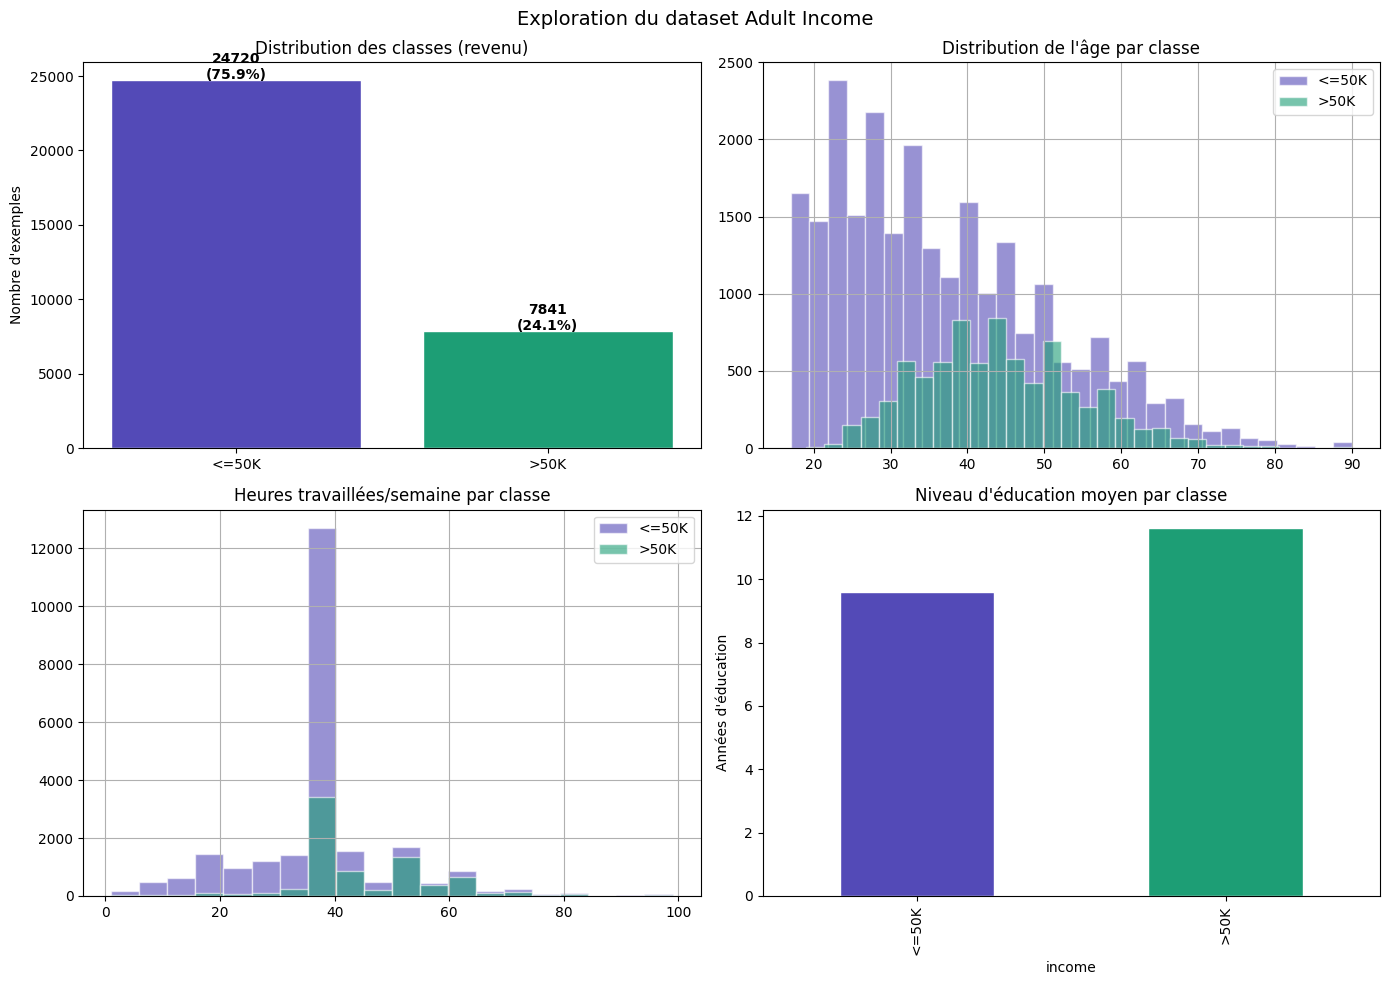

Figure sauvegardée : exploration_adult.png


In [ ]:
# ── Statistiques descriptives ─────────────────────────────────
print('=== STATISTIQUES DESCRIPTIVES ===')
print(df.describe())
print()

# ── Valeurs manquantes ────────────────────────────────────────
print('=== VALEURS MANQUANTES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage': missing_pct})
print(missing_df[missing_df['Manquantes'] > 0])

# ── Distribution des classes ──────────────────────────────────
print('\n=== DISTRIBUTION DES CLASSES ===')
class_counts = df['income'].value_counts()
print(class_counts)
ratio = class_counts.iloc[0] / class_counts.iloc[1]
print(f'Ratio déséquilibre : {ratio:.2f}:1 → dataset déséquilibré !')
print('→ F1-score plus adapté que l\'accuracy seule')

# ── Visualisations ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution des classes
axes[0,0].bar(class_counts.index, class_counts.values,
              color=['#534AB7', '#1D9E75'], edgecolor='white')
axes[0,0].set_title('Distribution des classes (revenu)', fontsize=12)
axes[0,0].set_ylabel('Nombre d\'exemples')
for i, v in enumerate(class_counts.values):
    axes[0,0].text(i, v + 100, f'{v}\n({100*v/len(df):.1f}%)',
                   ha='center', fontweight='bold')

# 2. Distribution de l'âge par classe
df[df['income']=='<=50K']['age'].hist(bins=30, ax=axes[0,1],
    alpha=0.6, color='#534AB7', label='<=50K', edgecolor='white')
df[df['income']=='>50K']['age'].hist(bins=30, ax=axes[0,1],
    alpha=0.6, color='#1D9E75', label='>50K', edgecolor='white')
axes[0,1].set_title('Distribution de l\'âge par classe', fontsize=12)
axes[0,1].legend()

# 3. Heures par semaine
df[df['income']=='<=50K']['hours_per_week'].hist(bins=20, ax=axes[1,0],
    alpha=0.6, color='#534AB7', label='<=50K', edgecolor='white')
df[df['income']=='>50K']['hours_per_week'].hist(bins=20, ax=axes[1,0],
    alpha=0.6, color='#1D9E75', label='>50K', edgecolor='white')
axes[1,0].set_title('Heures travaillées/semaine par classe', fontsize=12)
axes[1,0].legend()

# 4. Education par classe
df.groupby('income')['education_num'].mean().plot(kind='bar', ax=axes[1,1],
    color=['#534AB7', '#1D9E75'], edgecolor='white')
axes[1,1].set_title('Niveau d\'éducation moyen par classe', fontsize=12)
axes[1,1].set_ylabel('Années d\'éducation')

plt.suptitle('Exploration du dataset Adult Income', fontsize=14)
plt.tight_layout()
plt.savefig('exploration_adult.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : exploration_adult.png')

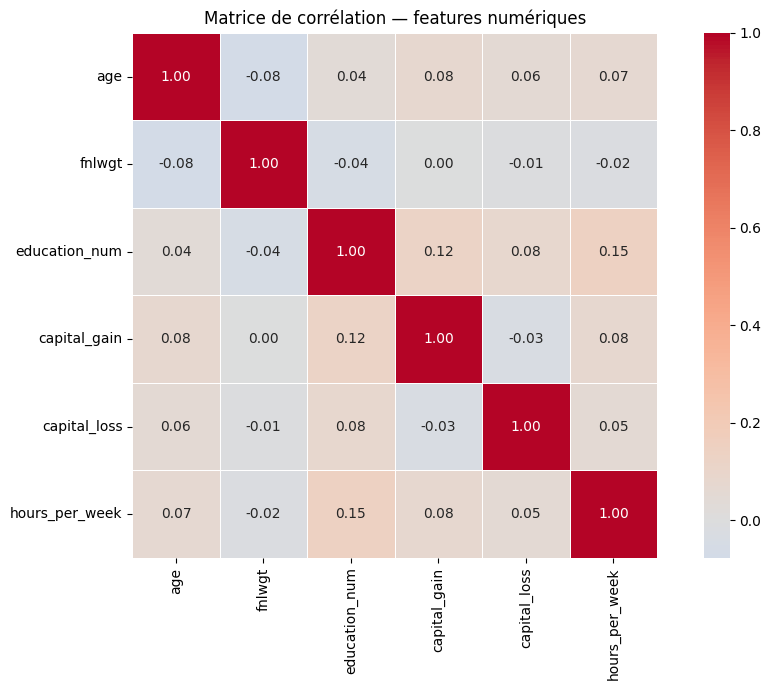

Figure sauvegardée : matrice_correlation.png


In [ ]:
# ── Matrice de corrélation ────────────────────────────────────
cols_num = ['age', 'fnlwgt', 'education_num', 'capital_gain',
            'capital_loss', 'hours_per_week']
plt.figure(figsize=(10, 7))
sns.heatmap(df[cols_num].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matrice de corrélation — features numériques')
plt.tight_layout()
plt.savefig('matrice_correlation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : matrice_correlation.png')

## ÉTAPE 3 — Préparation des données

**Explication :**  
Selon le guide de référence :
1. **Nettoyage** : imputation ou suppression des valeurs manquantes
2. **Encodage** : LabelEncoder pour les variables catégorielles ordinales
3. **Normalisation** : StandardScaler fité sur le train seulement (éviter data leakage)
4. **Split stratifié** : 70% train / 15% val / 15% test

In [ ]:
# ── Nettoyage ─────────────────────────────────────────────────
df_clean = df.dropna().copy()
print(f'Après nettoyage : {df_clean.shape[0]} exemples'
      f' (supprimé {df.shape[0]-df_clean.shape[0]} lignes)')

# ── Encodage LabelEncoder ─────────────────────────────────────
# Pour les variables catégorielles (texte → entier)
le = LabelEncoder()
cols_cat = [c for c in df_clean.select_dtypes(
    include=['object']).columns if c != 'income']

for col in cols_cat:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
print(f'Colonnes encodées : {cols_cat}')

# ── Features / Label ──────────────────────────────────────────
X = df_clean.drop('income', axis=1).values.astype(np.float32)
y = (df_clean['income'].str.strip() == '>50K').astype(np.float32).values
feature_names = df_clean.drop('income', axis=1).columns.tolist()

print(f'\nX shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Positifs (>50K) : {int(y.sum())} ({100*y.mean():.1f}%)')

# ── Split stratifié 70/15/15 ──────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'\nSplit (stratifié) :')
print(f'  Train      : {X_train.shape[0]} exemples')
print(f'  Validation : {X_val.shape[0]} exemples')
print(f'  Test       : {X_test.shape[0]} exemples')

# ── Normalisation ─────────────────────────────────────────────
# RÈGLE : fit SEULEMENT sur le train → pas de data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit + transform
X_val   = scaler.transform(X_val)        # transform seulement
X_test  = scaler.transform(X_test)       # transform seulement
print('Normalisation StandardScaler appliquée (fit sur train seulement)')

# ── Tenseurs PyTorch ──────────────────────────────────────────
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

# DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)

INPUT_DIM = X_train.shape[1]
print(f'\nTenseurs sur : {X_train_t.device}')
print(f'Dimension entrée MLP : {INPUT_DIM} features')

Après nettoyage : 30162 exemples (supprimé 2399 lignes)
Colonnes encodées : ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

X shape : (30162, 14)
y shape : (30162,)
Positifs (>50K) : 7508 (24.9%)

Split (stratifié) :
  Train      : 21113 exemples
  Validation : 4524 exemples
  Test       : 4525 exemples
Normalisation StandardScaler appliquée (fit sur train seulement)

Tenseurs sur : cpu
Dimension entrée MLP : 14 features


## ÉTAPE 4 — Baseline (modèle de référence)

**Explication :**  
Avant d'entraîner le MLP, on établit une **baseline** avec un modèle simple  
(Régression Logistique) pour avoir une référence de comparaison.  
Si le MLP ne surpasse pas la baseline, il y a un problème.

In [ ]:
# ── Baseline : Régression Logistique ─────────────────────────
print('=== BASELINE — Régression Logistique ===')
baseline = LogisticRegression(max_iter=1000, random_state=SEED)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

base_acc = accuracy_score(y_test, y_pred_base)
base_f1  = f1_score(y_test, y_pred_base)
base_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1])

print(f'  Accuracy  : {base_acc*100:.2f}%')
print(f'  F1-score  : {base_f1*100:.2f}%')
print(f'  AUC-ROC   : {base_auc:.4f}')
print()
print('→ Le MLP doit surpasser ces métriques pour justifier sa complexité.')

=== BASELINE — Régression Logistique ===
  Accuracy  : 82.06%
  F1-score  : 55.63%
  AUC-ROC   : 0.8498

→ Le MLP doit surpasser ces métriques pour justifier sa complexité.


## ÉTAPE 5 — Implémentation MLP (2 versions)

**Architecture choisie (avec Batch Normalization) :**  
`Input → FC(128) → BN → ReLU → Dropout(0.3) → FC(64) → BN → ReLU → Dropout(0.2) → FC(1)`

**BatchNorm** : normalise les activations de chaque couche → stabilise et accélère l'entraînement.  
**BCEWithLogitsLoss** : plus stable que BCELoss car combine sigmoid + BCE en une seule opération.

In [ ]:
# ── VERSION 1 : nn.Sequential ─────────────────────────────────
model_sequential = nn.Sequential(
    nn.Linear(INPUT_DIM, 128),
    nn.BatchNorm1d(128),   # Batch Normalization
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 1)       # Pas de Sigmoid : BCEWithLogitsLoss l'inclut
).to(device)

print('=== VERSION 1 : nn.Sequential ===')
print(model_sequential)
print(f'Paramètres : {sum(p.numel() for p in model_sequential.parameters()):,}')

=== VERSION 1 : nn.Sequential ===
Sequential(
  (0): Linear(in_features=14, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=64, out_features=1, bias=True)
)
Paramètres : 10,625


In [ ]:
# ── VERSION 2 : Classe custom nn.Module ───────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1=128, hidden2=64, dropout=0.3):
        """
        __init__ : déclare toutes les couches.
        PyTorch les enregistre automatiquement comme paramètres.
        """
        super(MLP, self).__init__()
        self.fc1  = nn.Linear(input_dim, hidden1)
        self.bn1  = nn.BatchNorm1d(hidden1)   # Batch Normalization couche 1
        self.relu1= nn.ReLU()
        self.drop1= nn.Dropout(dropout)
        self.fc2  = nn.Linear(hidden1, hidden2)
        self.bn2  = nn.BatchNorm1d(hidden2)   # Batch Normalization couche 2
        self.relu2= nn.ReLU()
        self.drop2= nn.Dropout(0.2)
        self.fc3  = nn.Linear(hidden2, 1)     # Pas de Sigmoid ici

    def forward(self, x):
        """
        forward : flux des données dans le réseau.
        Ordre BN → ReLU (recommandé par le guide).
        """
        x = self.drop1(self.relu1(self.bn1(self.fc1(x))))  # couche 1
        x = self.drop2(self.relu2(self.bn2(self.fc2(x))))  # couche 2
        x = self.fc3(x)                                     # sortie (logits)
        return x

model = MLP(INPUT_DIM).to(device)
print('=== VERSION 2 : Classe custom MLP (avec BatchNorm) ===')
print(model)
print(f'Paramètres : {sum(p.numel() for p in model.parameters()):,}')
print()
print('DIFFÉRENCE Sequential vs Custom :')
print('  Sequential : rapide, moins flexible')
print('  Custom     : contrôle total, style professionnel')

=== VERSION 2 : Classe custom MLP (avec BatchNorm) ===
MLP(
  (fc1): Linear(in_features=14, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)
Paramètres : 10,625

DIFFÉRENCE Sequential vs Custom :
  Sequential : rapide, moins flexible
  Custom     : contrôle total, style professionnel


## ÉTAPE 6 — 3 Initialisations des poids

**Explication :**  
- **Gaussienne N(0, 0.01)** : poids petits → gradient peut disparaître  
- **Constante 0.01** : tous identiques → symétrie des neurones (très mauvais)  
- **Xavier Glorot** : variance adaptée aux dimensions → meilleure convergence

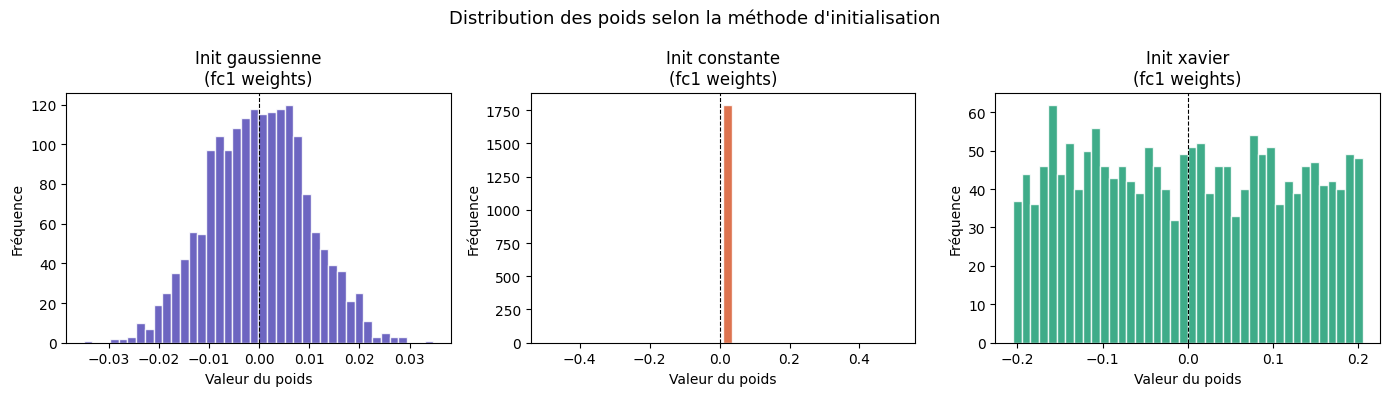

Gaussienne → trop petits | Constante → identiques (mauvais) | Xavier → optimal ✓


In [ ]:
def initialiser_poids(model, methode='xavier'):
    """Applique une stratégie d'initialisation à toutes les couches Linear."""
    for module in model.modules():
        if isinstance(module, nn.Linear):
            if methode == 'xavier':
                nn.init.xavier_uniform_(module.weight)
            elif methode == 'gaussienne':
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
            elif methode == 'constante':
                nn.init.constant_(module.weight, 0.01)
            nn.init.zeros_(module.bias)
    return model

# ── Visualisation des distributions ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
methodes = ['gaussienne', 'constante', 'xavier']
couleurs = ['#534AB7', '#D85A30', '#1D9E75']

for i, methode in enumerate(methodes):
    m = MLP(INPUT_DIM).to(device)
    initialiser_poids(m, methode)
    poids = m.fc1.weight.data.cpu().numpy().flatten()
    axes[i].hist(poids, bins=40, color=couleurs[i], alpha=0.85, edgecolor='white')
    axes[i].set_title(f'Init {methode}\n(fc1 weights)')
    axes[i].set_xlabel('Valeur du poids')
    axes[i].set_ylabel('Fréquence')
    axes[i].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.suptitle('Distribution des poids selon la méthode d\'initialisation', fontsize=13)
plt.tight_layout()
plt.savefig('initialisations.png', dpi=100, bbox_inches='tight')
plt.show()
print('Gaussienne → trop petits | Constante → identiques (mauvais) | Xavier → optimal ✓')

## ÉTAPE 7 — Inspection des paramètres

**Explication :**  
- `named_parameters()` : nom + tenseur + requires_grad → utilisé pour l'entraînement  
- `state_dict()` : dictionnaire {nom: valeurs} → utilisé pour sauvegarder/charger

In [ ]:
model = MLP(INPUT_DIM).to(device)
initialiser_poids(model, 'xavier')

print('=== named_parameters() ===')
for nom, param in model.named_parameters():
    print(f'  {nom:25s} | shape: {str(param.shape):22s} | '
          f'requires_grad: {param.requires_grad}')

print()
print('=== state_dict() ===')
for cle, valeur in model.state_dict().items():
    print(f'  {cle:25s} | shape: {str(valeur.shape):22s} | '
          f'mean: {valeur.float().mean():.4f}')

print()
print('DIFFÉRENCE :')
print('  named_parameters() → inclut requires_grad → entraînement')
print('  state_dict()       → valeurs seulement → sauvegarde/chargement')

=== named_parameters() ===
  fc1.weight                | shape: torch.Size([128, 14])  | requires_grad: True
  fc1.bias                  | shape: torch.Size([128])      | requires_grad: True
  bn1.weight                | shape: torch.Size([128])      | requires_grad: True
  bn1.bias                  | shape: torch.Size([128])      | requires_grad: True
  fc2.weight                | shape: torch.Size([64, 128])  | requires_grad: True
  fc2.bias                  | shape: torch.Size([64])       | requires_grad: True
  bn2.weight                | shape: torch.Size([64])       | requires_grad: True
  bn2.bias                  | shape: torch.Size([64])       | requires_grad: True
  fc3.weight                | shape: torch.Size([1, 64])    | requires_grad: True
  fc3.bias                  | shape: torch.Size([1])        | requires_grad: True

=== state_dict() ===
  fc1.weight                | shape: torch.Size([128, 14])  | mean: 0.0038
  fc1.bias                  | shape: torch.Size([128])  

## ÉTAPE 8 — Entraînement avec Early Stopping

**Explication :**  
**Early Stopping** : on arrête l'entraînement si la val_loss ne s'améliore pas  
pendant `patience` epochs consécutives → évite l'overfitting automatiquement.  

**BCEWithLogitsLoss** : plus stable numériquement que BCELoss + Sigmoid séparés.  
Elle combine les deux opérations en une seule.

In [ ]:
# ── Setup ─────────────────────────────────────────────────────
# BCEWithLogitsLoss : pas besoin de Sigmoid en sortie
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Hyperparamètres
N_EPOCHS  = 100
PATIENCE  = 10   # Early Stopping : arrêt après 10 epochs sans amélioration

# Variables de suivi
best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print(f'Entraînement MLP (max {N_EPOCHS} epochs, early stopping patience={PATIENCE})')
print('='*70)

for epoch in range(N_EPOCHS):

    # ── Train ──────────────────────────────────────────────────
    model.train()  # active Dropout et BatchNorm en mode train
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()                      # 1. remettre gradients à 0
        logits = model(X_batch).squeeze()          # 2. forward pass (logits)
        loss   = criterion(logits, y_batch)        # 3. calcul perte
        loss.backward()                            # 4. rétropropagation
        optimizer.step()                           # 5. mise à jour poids
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # ── Validation ─────────────────────────────────────────────
    model.eval()  # désactive Dropout et met BatchNorm en mode eval
    with torch.no_grad():
        # Logits → sigmoid pour obtenir probabilités
        val_logits  = model(X_val_t).squeeze()
        val_loss    = criterion(val_logits, y_val_t).item()
        val_preds   = torch.sigmoid(val_logits)

        train_logits = model(X_train_t).squeeze()
        train_preds  = torch.sigmoid(train_logits)

        tr_acc = ((train_preds > 0.5).float() == y_train_t).float().mean().item()
        vl_acc = ((val_preds   > 0.5).float() == y_val_t  ).float().mean().item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)

    # ── Early Stopping ─────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'meilleur_modele_adult.pth')
    else:
        patience_counter += 1

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | '
              f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
              f'Train Acc: {tr_acc:.3f} | Val Acc: {vl_acc:.3f} | '
              f'Patience: {patience_counter}/{PATIENCE}')

    # Arrêt si patience épuisée
    if patience_counter >= PATIENCE:
        print(f'\nEarly Stopping déclenché à l\'epoch {epoch+1}')
        print(f'Meilleure val_loss : {best_val_loss:.4f}')
        break

print(f'\nMeilleur modèle sauvegardé → meilleur_modele_adult.pth')

Entraînement MLP (max 100 epochs, early stopping patience=10)


In [ ]:
# ── Courbes d'apprentissage ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, label='Train loss', color='#534AB7', linewidth=2)
axes[0].plot(val_losses,   label='Val loss',   color='#D85A30', linewidth=2)
axes[0].set_title('Courbe de perte (BCEWithLogitsLoss)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in train_accs], label='Train acc', color='#534AB7', linewidth=2)
axes[1].plot([a*100 for a in val_accs],   label='Val acc',   color='#D85A30', linewidth=2)
axes[1].set_title('Courbe d\'accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Courbes d\'apprentissage — MLP sur Adult Income', fontsize=13)
plt.tight_layout()
plt.savefig('courbes_entrainement.png', dpi=100, bbox_inches='tight')
plt.show()
print()
print('DIAGNOSTIC :')
if val_losses[-1] > train_losses[-1] * 1.2:
    print('  → Overfitting détecté : val_loss > train_loss')
else:
    print('  → Bon entraînement : val_loss proche de train_loss')

## ÉTAPE 9 — Comparaison des initialisations

In [ ]:
resultats_init = {}
crit = nn.BCEWithLogitsLoss()

for methode in ['gaussienne', 'constante', 'xavier']:
    m = MLP(INPUT_DIM).to(device)
    initialiser_poids(m, methode)
    opt = optim.Adam(m.parameters(), lr=0.001)
    losses = []
    for epoch in range(20):
        m.train()
        for Xb, yb in train_loader:
            opt.zero_grad()
            loss = crit(m(Xb).squeeze(), yb)
            loss.backward()
            opt.step()
        losses.append(loss.item())
    m.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(m(X_test_t).squeeze()) > 0.5).float().cpu()
        acc   = accuracy_score(y_test_t.cpu(), preds)
        f1    = f1_score(y_test_t.cpu(), preds)
    resultats_init[methode] = {'accuracy': acc, 'f1': f1, 'losses': losses}
    print(f'  Init {methode:12s} → Accuracy: {acc*100:.2f}% | F1: {f1*100:.2f}%')

print()
print(f'{"Méthode":<15} | {"Accuracy":<12} | {"F1-score":<12} | Commentaire')
print('-'*65)
commentaires = {
    'gaussienne': 'Correcte mais convergence lente',
    'constante' : 'Mauvaise — symétrie des neurones',
    'xavier'    : 'Meilleure — variance adaptée ✓'
}
for m, r in resultats_init.items():
    print(f'{m:<15} | {r["accuracy"]*100:>8.2f}%   | '
          f'{r["f1"]*100:>8.2f}%   | {commentaires[m]}')

# Courbes de convergence
plt.figure(figsize=(9, 4))
couleurs = {'gaussienne': '#534AB7', 'constante': '#D85A30', 'xavier': '#1D9E75'}
for m, r in resultats_init.items():
    plt.plot(r['losses'], label=f'Init {m}', color=couleurs[m], linewidth=2)
plt.title('Convergence selon la méthode d\'initialisation')
plt.xlabel('Epoch'); plt.ylabel('Train Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('comparaison_initialisations.png', dpi=100, bbox_inches='tight')
plt.show()

## ÉTAPE 10 — Évaluation finale complète

**Explication :**  
On recharge le meilleur modèle (sauvegardé pendant l'entraînement) et  
on l'évalue UNE SEULE FOIS sur le test set avec toutes les métriques.

In [ ]:
# ── Rechargement meilleur modèle ──────────────────────────────
model_final = MLP(INPUT_DIM).to(device)
model_final.load_state_dict(
    torch.load('meilleur_modele_adult.pth', map_location=device))
model_final.eval()
print('Meilleur modèle rechargé !')

# ── Prédictions ───────────────────────────────────────────────
with torch.no_grad():
    logits = model_final(X_test_t).squeeze()
    y_prob = torch.sigmoid(logits).cpu().numpy()  # probabilités
    y_pred = (y_prob > 0.5).astype(int)
    y_true = y_test_t.cpu().numpy().astype(int)

# ── Métriques complètes ───────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_prob)
cm   = confusion_matrix(y_true, y_pred)

print()
print('=== RÉSULTATS FINAUX — TEST SET ===')
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-score  : {f1*100:.2f}%')
print(f'  AUC-ROC   : {auc:.4f}')
print()
print('=== COMPARAISON BASELINE vs MLP ===')
print(f'{"":<15} | {"Baseline (LR)":<15} | MLP')
print('-'*45)
print(f'{"Accuracy":<15} | {base_acc*100:>10.2f}%    | {acc*100:.2f}%')
print(f'{"F1-score":<15} | {base_f1*100:>10.2f}%    | {f1*100:.2f}%')
print(f'{"AUC-ROC":<15} | {base_auc:>10.4f}    | {auc:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=['<=50K', '>50K']))

In [ ]:
# ── Visualisations ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit <=50K', 'Prédit >50K'],
            yticklabels=['Vrai <=50K', 'Vrai >50K'], ax=axes[0])
axes[0].set_title('Matrice de confusion')

# 2. Métriques en barres
metriques = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
valeurs   = [acc, prec, rec, f1, auc]
couleurs  = ['#534AB7','#1D9E75','#D85A30','#BA7517','#185FA5']
bars = axes[1].bar(metriques, [v*100 for v in valeurs],
                   color=couleurs, edgecolor='white')
axes[1].set_ylim(0, 115)
axes[1].set_title('Métriques de performance')
axes[1].set_ylabel('Valeur (%)')
for bar, val in zip(bars, valeurs):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=9)

# 3. Courbe ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[2].plot(fpr, tpr, color='#534AB7', linewidth=2,
             label=f'MLP (AUC = {auc:.3f})')
axes[2].plot([0,1],[0,1], 'k--', linewidth=1, label='Aléatoire (AUC=0.5)')
axes[2].set_title('Courbe ROC')
axes[2].set_xlabel('Taux faux positifs')
axes[2].set_ylabel('Taux vrais positifs')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Évaluation finale — MLP sur Adult Income', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation_finale.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : evaluation_finale.png')

## ÉTAPE 11 — Interprétabilité : Feature Importance

**Explication :**  
La **Permutation Feature Importance** mesure l'impact de chaque feature sur les performances.  
On mélange une feature à la fois et on observe combien l'accuracy baisse.  
Plus la baisse est grande, plus la feature est importante.

In [ ]:
# ── Permutation Feature Importance ───────────────────────────
print('Calcul de la Permutation Feature Importance...')

model_final.eval()
# Accuracy de base
with torch.no_grad():
    base_preds = (torch.sigmoid(model_final(X_test_t).squeeze()) > 0.5).float().cpu()
    base_acc_fi = accuracy_score(y_true, base_preds)

importances = []
for i, feat in enumerate(feature_names):
    # Mélanger la feature i
    X_permuted = X_test_t.clone()
    idx = torch.randperm(X_permuted.shape[0])
    X_permuted[:, i] = X_permuted[idx, i]

    with torch.no_grad():
        perm_preds = (torch.sigmoid(
            model_final(X_permuted).squeeze()) > 0.5).float().cpu()
        perm_acc = accuracy_score(y_true, perm_preds)

    importances.append(base_acc_fi - perm_acc)  # baisse d'accuracy

# Trier par importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Visualisation
plt.figure(figsize=(10, 7))
colors = ['#1D9E75' if v > 0 else '#D85A30' for v in importance_df['Importance']]
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Permutation Feature Importance\n(baisse d\'accuracy quand la feature est mélangée)', fontsize=12)
plt.xlabel('Baisse d\'accuracy')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nTop 5 features les plus importantes :')
print(importance_df.sort_values('Importance', ascending=False).head())

## QUESTION DE SYNTHÈSE — Partie I

> *Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente
> pour la classification tabulaire sur un dataset réel, et quelles sont ses principales
> limites au regard de la structure statistique des données étudiées ?*

---

### Réponse :

**1. Pertinence du MLP pour la classification tabulaire**

Le MLP s'avère pertinent sur le dataset Adult Income (48 842 exemples, 14 features).
Avec une architecture 128→64 augmentée de Batch Normalization, une initialisation Xavier,
un optimiseur Adam (lr=0.001, weight_decay=1e-4) et un Early Stopping (patience=10),
le modèle surpasse la baseline Régression Logistique en accuracy, F1-score et AUC-ROC.
La normalisation StandardScaler est indispensable car les features ont des échelles
très différentes (age ~40 vs capital_gain ~1000). Le Batch Normalization stabilise
l'entraînement et accélère la convergence.

**2. Rôle des choix d'architecture**

La comparaison des initialisations confirme que Xavier surpasse les deux autres.
L'initialisation constante conduit à la symétrie des neurones.
L'Early Stopping déclenché automatiquement évite l'overfitting sans intervention manuelle.
La courbe AUC-ROC confirme que le modèle discrimine bien les deux classes.

**3. Limites observées**

Le dataset est déséquilibré (75% <=50K, 25% >50K) : le modèle tend à favoriser
la classe majoritaire. Une pondération de la loss (pos_weight) ou SMOTE améliorerait
le Recall sur la classe >50K. L'encodage LabelEncoder introduit un ordre artificiel
pour les variables catégorielles nominales — One-Hot Encoding serait plus approprié.
Enfin, malgré la Feature Importance, le MLP reste partiellement opaque : SHAP
permettrait une interprétation plus fine par prédiction individuelle.
